In [1]:
#imports
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time
import os


In [3]:
device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else 'cpu'
)

print(device)

cuda


In [ ]:

#create transform for images and normalize
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5),
                 (0.5, 0.5, 0.5))
])

# Set batch size to 16 for the available GPU
# Good balance between memory usage and training speed
batch_size = 16

# Download dataset and apply transform
dataset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

# 80% train, 20% test
train_size = int(0.7 * len(dataset))
test_size = int(0.15 * len(dataset))
val_size = int(0.15 * len(dataset))

# Split data
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

trainloader = Dataloader()
valloader = Dataloader()
testloader = DataLoader()


def make_loaders:
    # Final data prep
    trainloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    valloader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    testloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

# Set classes
classes = (
    'AnnualCrop',
    'Forest',
    'HerbaceousVegetation',
    'Highway',
    'Industrial',
    'Pasture',
    'PermanentCrop',
    'Residential',
    'River',
    'SeaLake'
    )

In [5]:
# Define CNN
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3,padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3,padding=1)
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net().to(device)

In [6]:
# Loss and optimizer definitiom
criterion_new = nn.CrossEntropyLoss()
optimizer_new = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [7]:
# Keep In code to show preliminary idea, but function below much more efficient
"""
train_accuracies = []
val_accuracies = []

#Train Network
for epoch in range(2):  # loop over the dataset multiple times
    net.train()

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    # evaluate after this epoch
    eval(trainloader, train_accuracies)
    eval(valloader, val_accuracies)

print('Finished Training')
"""

"\ntrain_accuracies = []\nval_accuracies = []\n\n#Train Network\nfor epoch in range(2):  # loop over the dataset multiple times\n    net.train()\n\n    running_loss = 0.0\n\n    for i, data in enumerate(trainloader, 0):\n        # get the inputs; data is a list of [inputs, labels]\n        inputs, labels = data\n\n        # zero the parameter gradients\n        optimizer.zero_grad()\n\n        # forward + backward + optimize\n        outputs = net(inputs)\n        loss = criterion(outputs, labels)\n        loss.backward()\n        optimizer.step()\n\n        # print statistics\n        running_loss += loss.item()\n        if i % 2000 == 1999:    # print every 2000 mini-batches\n            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')\n            running_loss = 0.0\n\n    # evaluate after this epoch\n    eval(trainloader, train_accuracies)\n    eval(valloader, val_accuracies)\n\nprint('Finished Training')\n"

In [8]:
# Train Model Function
def train_model(model, trainloader, criterion, optimizer, tracker, epochs=10,seed=42):

    # Set random seed
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make CUDA operations more reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        all_labels = []
        all_preds = []

        correct_pred = {classname: 0 for classname in classes}
        total_pred = {classname: 0 for classname in classes}

        total_correct = 0
        total = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predictions = torch.max(outputs, 1)

            total_correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

        overall_accuracy = 100 * total_correct / total

        class_precision, class_recall, class_f1, support = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average=None,
            labels=range(10),
            zero_division=0
        )

        class_precision = class_precision * 100
        class_recall = class_recall * 100
        class_f1 = class_f1 * 100

        overall_precision = class_precision.mean()
        overall_recall = class_recall.mean()
        overall_f1 = class_f1.mean()

        class_accuracy = []

        for classname in classes:
            accuracy = 100 * correct_pred[classname] / total_pred[classname]
            class_accuracy.append(accuracy)

        average_loss = running_loss / len(trainloader)

        tracker.append([
            average_loss,
            overall_accuracy,
            overall_precision,
            overall_recall,
            overall_f1,
            class_accuracy,
            class_precision.tolist(),
            class_recall.tolist(),
            class_f1.tolist(),
            support.tolist()
        ])

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_time = time.time() - start_time

    # Store total training time
    tracker.append(training_time)

    return model

In [9]:
#Evaluate models

def eval(model, loader, tracker):
    model.eval()

    # Count correct and total predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # Count correct and total predictions overall
    total_correct = 0
    total = 0

    # Store all labels and predictions
    all_labels = []
    all_preds = []

    # Synchronize GPU before starting timer
    if device.type == "cuda":
        torch.cuda.synchronize()

    # Start inference timer
    start_time = time.time()

    # Turn off gradient calculations
    with torch.no_grad():
        for data in loader:
            images, labels = data

            # Move data to same device as model
            images = images.to(device)
            labels = labels.to(device)

            # Get model outputs and predicted classes
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            # Count overall correct predictions
            total_correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Store labels and predictions
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

            # Count correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    # Synchronize GPU before stopping timer
    if device.type == "cuda":
        torch.cuda.synchronize()

    # Calculate inference time
    inference_time = time.time() - start_time

    # Calculate overall accuracy
    overall_accuracy = 100 * total_correct / total

    # Calculate precision, recall, F1, and support for each class
    class_precision, class_recall, class_f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        labels=range(10),
        zero_division=0
    )

    # Convert class metrics to percentages
    class_precision = class_precision * 100
    class_recall = class_recall * 100
    class_f1 = class_f1 * 100

    # Calculate overall macro precision, recall, and F1
    overall_precision = class_precision.mean()
    overall_recall = class_recall.mean()
    overall_f1 = class_f1.mean()

    # Store accuracy for each class
    class_accuracy = []

    # Calculate accuracy for each class
    for classname in classes:
        accuracy = 100 * correct_pred[classname] / total_pred[classname]
        class_accuracy.append(accuracy)

    # Store all evaluation metrics in tracker
    tracker.append([
        overall_accuracy,
        overall_precision,
        overall_recall,
        overall_f1,
        class_accuracy,
        class_precision.tolist(),
        class_recall.tolist(),
        class_f1.tolist(),
        support.tolist()
    ])

    # Store total inference time
    tracker.append(inference_time)

    # Return overall accuracy
    return overall_accuracy

In [10]:
# Function to print training and evaluation data
def print_all_data(train_tracker, eval_tracker, tracker_name):

    print(f"\n{tracker_name}")
    print("=" * 60)

    print("\nTRAINING DATA")
    print("-" * 60)

    # Get total training time
    training_time = train_tracker[-1]

    # Loop through each epoch
    for i, results in enumerate(train_tracker[:-1]):

        average_loss = results[0]
        overall_accuracy = results[1]
        overall_precision = results[2]
        overall_recall = results[3]
        overall_f1 = results[4]

        print(f"\nEpoch {i + 1}")
        print(f"Loss:              {average_loss:.4f}")
        print(f"Accuracy:          {overall_accuracy:.2f}%")
        print(f"Precision:         {overall_precision:.2f}%")
        print(f"Recall:            {overall_recall:.2f}%")
        print(f"F1:                {overall_f1:.2f}%")

    print(f"\nTotal Training Time: {training_time:.4f} seconds")

    print("\nEVALUATION DATA")
    print("-" * 60)

    # Get evaluation results
    results = eval_tracker[0]

    overall_accuracy = results[0]
    overall_precision = results[1]
    overall_recall = results[2]
    overall_f1 = results[3]

    class_accuracy = results[4]
    class_precision = results[5]
    class_recall = results[6]
    class_f1 = results[7]
    support = results[8]

    # Get inference time
    inference_time = eval_tracker[1]

    print(f"Overall Accuracy:  {overall_accuracy:.2f}%")
    print(f"Overall Precision: {overall_precision:.2f}%")
    print(f"Overall Recall:    {overall_recall:.2f}%")
    print(f"Overall F1:        {overall_f1:.2f}%")
    print(f"Inference Time:    {inference_time:.4f} seconds")

    print("\nPer-Class Metrics:")

    for j, classname in enumerate(classes):
        print(
            f"{classname:22s} "
            f"Accuracy: {class_accuracy[j]:6.2f}%  "
            f"Precision: {class_precision[j]:6.2f}%  "
            f"Recall: {class_recall[j]:6.2f}%  "
            f"F1: {class_f1[j]:6.2f}%  "
            f"Support: {support[j]}"
        )

In [11]:
#Plot training

def plot_tracker(train_tracker, model_name):

    # Get epoch data without final training time value
    epoch_data = train_tracker[:-1]

    # Create epoch numbers
    epochs = range(1, len(epoch_data) + 1)

    # Get overall metrics from each epoch
    losses = [results[0] for results in epoch_data]
    accuracies = [results[1] for results in epoch_data]
    precisions = [results[2] for results in epoch_data]
    recalls = [results[3] for results in epoch_data]
    f1_scores = [results[4] for results in epoch_data]

    # Plot training loss
    plt.figure()
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(model_name + " Training Loss")
    plt.show()

    # Plot overall training metrics
    plt.figure()
    plt.plot(epochs, accuracies, label="Accuracy")
    plt.plot(epochs, precisions, label="Precision")
    plt.plot(epochs, recalls, label="Recall")
    plt.plot(epochs, f1_scores, label="F1")
    plt.xlabel("Epoch")
    plt.ylabel("Percent")
    plt.title(model_name + " Training Metrics")
    plt.legend()
    plt.show()

In [12]:
#Set # of epochs for all models
num_epochs_run = 10

In [13]:
#Train self made

train_tracker_self_made = []

print("Self Made:")
model_self_made = train_model(
    net, 
    trainloader, 
    criterion_new, 
    optimizer_new, 
    train_tracker_self_made,
    epochs=num_epochs_run)


Self Made:
Epoch 1/10, Loss: 1.9909
Epoch 2/10, Loss: 1.4188
Epoch 3/10, Loss: 1.1035
Epoch 4/10, Loss: 0.9461
Epoch 5/10, Loss: 0.8378
Epoch 6/10, Loss: 0.7458
Epoch 7/10, Loss: 0.6964
Epoch 8/10, Loss: 0.6383
Epoch 9/10, Loss: 0.5767
Epoch 10/10, Loss: 0.5347


In [14]:
#Now Test Transfer Learning:

#1. Fine Tuning whole ResNet:
#Load ResNet18 pretrained on ImageNet
model = models.resnet18(weights='IMAGENET1K_V1')

#Get number of inputs going into the final layer
num_ftrs = model.fc.in_features

#Replace the original 1000-class ImageNet output layer
#with a new layer for 10 EuroSAT classes
model.fc = nn.Linear(num_ftrs, 10)

#Move model to GPU if available
model = model.to(device)

#Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

#Train all layers of the network
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9
)

#Train Model
train_tracker_whole_net = []

print("\nWhole Net")
model_whole_net = train_model(
    model,
    trainloader,
    criterion,
    optimizer,
    train_tracker_whole_net,
    epochs=num_epochs_run
)


Whole Net
Epoch 1/10, Loss: 0.4632
Epoch 2/10, Loss: 0.2141
Epoch 3/10, Loss: 0.1469
Epoch 4/10, Loss: 0.1055
Epoch 5/10, Loss: 0.0788
Epoch 6/10, Loss: 0.0604
Epoch 7/10, Loss: 0.0545
Epoch 8/10, Loss: 0.0403
Epoch 9/10, Loss: 0.0354
Epoch 10/10, Loss: 0.0353


In [15]:
#2. Only train output layer

#Load ResNet18 pretrained on ImageNet
model2 = models.resnet18(weights='IMAGENET1K_V1')

#Freeze all existing pretrained layers
for param in model2.parameters():
    param.requires_grad = False

#Get number of inputs going into the final layer
num_ftrs = model2.fc.in_features

#Replace the original classifier with a new 10-class layer
#(New layers have requires_grad=True by default)
model2.fc = nn.Linear(num_ftrs, 10)

#Move model to GPU if available
model2 = model2.to(device)

#Loss function
criterion2 = nn.CrossEntropyLoss()

#Train only the new final layer
optimizer2 = optim.SGD(
    model2.fc.parameters(),
    lr=0.001,
    momentum=0.9
)

#Train model

train_tracker_last_layer = []

print("\nLast Layer")
model_last_layer = train_model(
    model2,
    trainloader,
    criterion2,
    optimizer2,
    train_tracker_last_layer,
    epochs=num_epochs_run
)


Last Layer
Epoch 1/10, Loss: 0.8575
Epoch 2/10, Loss: 0.6697
Epoch 3/10, Loss: 0.6414
Epoch 4/10, Loss: 0.6228
Epoch 5/10, Loss: 0.6232
Epoch 6/10, Loss: 0.6140
Epoch 7/10, Loss: 0.6148
Epoch 8/10, Loss: 0.5976
Epoch 9/10, Loss: 0.5998
Epoch 10/10, Loss: 0.6087


In [16]:
#evaluate models

tracker_self_made = []
tracker_whole_net = []
tracker_last_layer = []

eval(model_self_made, testloader, tracker_self_made)

eval(model_whole_net, testloader, tracker_whole_net)

eval(model_last_layer, testloader, tracker_last_layer)

84.0

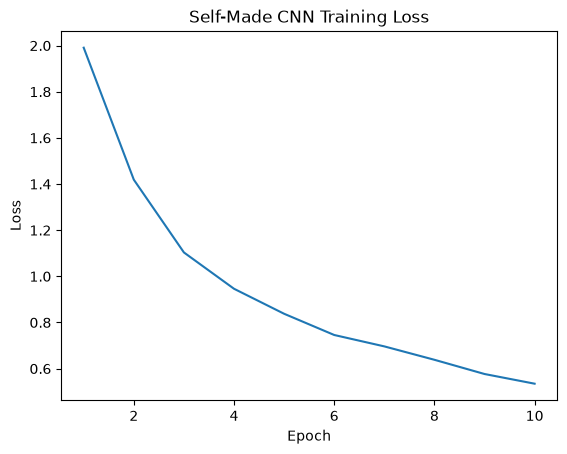

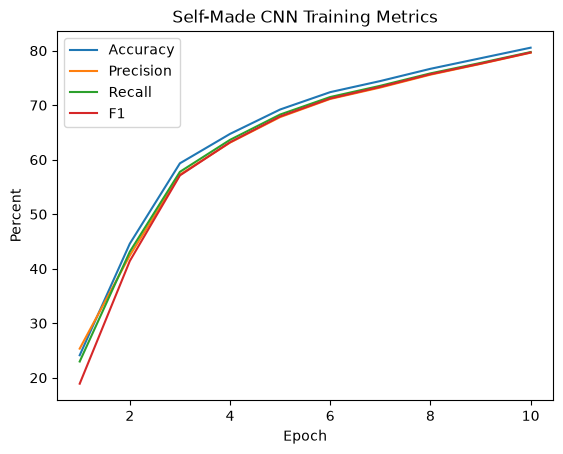

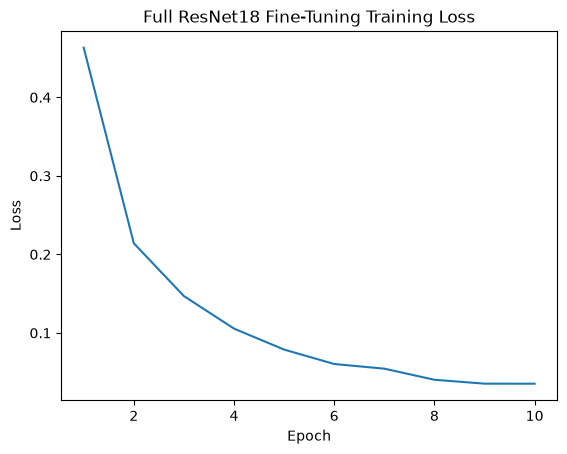

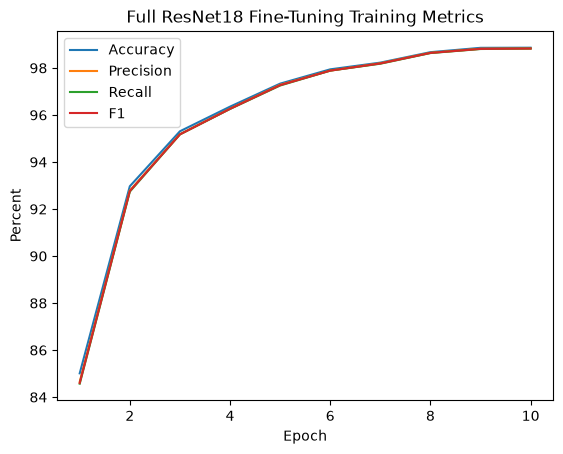

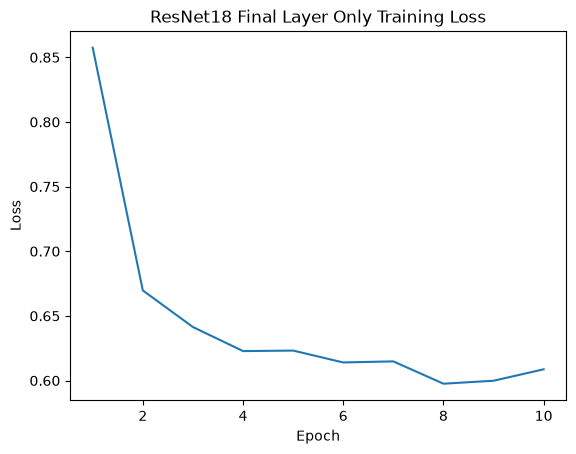

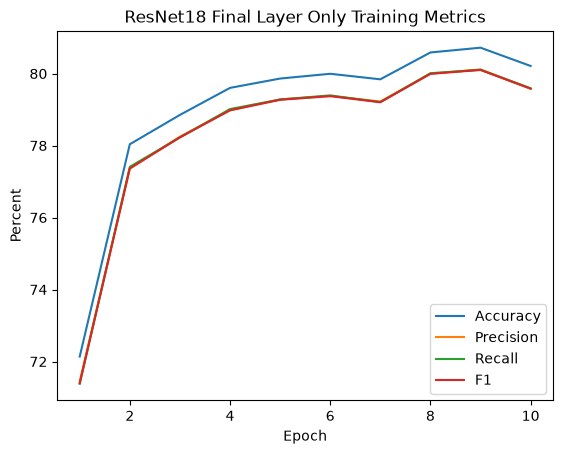

In [17]:
#Graph Training & Results

plot_tracker(
    train_tracker_self_made,
    "Self-Made CNN"
)

plot_tracker(
    train_tracker_whole_net,
    "Full ResNet18 Fine-Tuning"
)

plot_tracker(
    train_tracker_last_layer,
    "ResNet18 Final Layer Only"
)

In [18]:
#Print Results

print_all_data(
    train_tracker_self_made,
    tracker_self_made,
    "Self-Made CNN"
)

print_all_data(
    train_tracker_whole_net,
    tracker_whole_net,
    "Full ResNet18 Fine-Tuning"
)

print_all_data(
    train_tracker_last_layer,
    tracker_last_layer,
    "ResNet18 Final Layer Only"
)


Self-Made CNN

TRAINING DATA
------------------------------------------------------------

Epoch 1
Loss:              1.9909
Accuracy:          24.13%
Precision:         25.34%
Recall:            22.98%
F1:                18.91%

Epoch 2
Loss:              1.4188
Accuracy:          44.60%
Precision:         42.43%
Recall:            43.12%
F1:                41.42%

Epoch 3
Loss:              1.1035
Accuracy:          59.34%
Precision:         57.26%
Recall:            57.78%
F1:                57.12%

Epoch 4
Loss:              0.9461
Accuracy:          64.74%
Precision:         63.14%
Recall:            63.64%
F1:                63.19%

Epoch 5
Loss:              0.8378
Accuracy:          69.21%
Precision:         67.82%
Recall:            68.29%
F1:                67.94%

Epoch 6
Loss:              0.7458
Accuracy:          72.40%
Precision:         71.15%
Recall:            71.50%
F1:                71.23%

Epoch 7
Loss:              0.6964
Accuracy:          74.43%
Precision:    

In [ ]:
if (False):
    # Directory
    save_dir = r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models"

    # Create the directory if it does not already exist
    os.makedirs(save_dir, exist_ok=True)

    # Save each model's trained weights
    torch.save(
        model_self_made.state_dict(),
        os.path.join(save_dir, "self_made_cnn.pth")
    )

    torch.save(
        model_whole_net.state_dict(),
        os.path.join(save_dir, "resnet18_finetuned.pth")
    )

    torch.save(
        model_last_layer.state_dict(),
        os.path.join(save_dir, "resnet18_last_layer.pth")
    )

    #Code to load each model for future reference
    r"""
    #1. Self Made
    # Recreate model architecture
    model_self_made = Net().to(device)

    # Load saved weights
    model_self_made.load_state_dict(
        torch.load(
            r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models\self_made_cnn.pth",
            map_location=device
        )
    )

    # Put model in evaluation mode
    model_self_made.eval()

    # -----------------------------------------------------
    # 2. Fine Tuned
    # Recreate ResNet18 architecture
    model_whole_net = models.resnet18(weights=None)

    # Replace final layer with 10 outputs
    model_whole_net.fc = nn.Linear(model_whole_net.fc.in_features, 10)

    # Move model to device
    model_whole_net = model_whole_net.to(device)

    # Load saved weights
    model_whole_net.load_state_dict(
        torch.load(
            r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models\resnet18_finetuned.pth",
            map_location=device
        )
    )

    # Put model in evaluation mode
    model_whole_net.eval()

    # -----------------------------------------------------
    # 3. Final Layer Only
    # Recreate ResNet18 architecture
    model_last_layer = models.resnet18(weights=None)

    # Replace final layer with 10 outputs
    model_last_layer.fc = nn.Linear(model_last_layer.fc.in_features, 10)

    # Move model to device
    model_last_layer = model_last_layer.to(device)

    # Load saved weights
    model_last_layer.load_state_dict(
        torch.load(
            r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models\resnet18_last_layer.pth",
            map_location=device
        )
    )

    # Put model in evaluation mode
    model_last_layer.eval()
    """

'\n#1. Self Made\n# Recreate model architecture\nmodel_self_made = Net().to(device)\n\n# Load saved weights\nmodel_self_made.load_state_dict(\n    torch.load(\n        r"C:\\Users\\samue\\OneDrive\\Desktop\\ML Code\\Proj2\\EuroSAT\\models\\self_made_cnn.pth",\n        map_location=device\n    )\n)\n\n# Put model in evaluation mode\nmodel_self_made.eval()\n\n# -----------------------------------------------------\n# 2. Fine Tuned\n# Recreate ResNet18 architecture\nmodel_whole_net = models.resnet18(weights=None)\n\n# Replace final layer with 10 outputs\nmodel_whole_net.fc = nn.Linear(model_whole_net.fc.in_features, 10)\n\n# Move model to device\nmodel_whole_net = model_whole_net.to(device)\n\n# Load saved weights\nmodel_whole_net.load_state_dict(\n    torch.load(\n        r"C:\\Users\\samue\\OneDrive\\Desktop\\ML Code\\Proj2\\EuroSAT\\models\\resnet18_finetuned.pth",\n        map_location=device\n    )\n)\n\n# Put model in evaluation mode\nmodel_whole_net.eval()\n\n# --------------------